# 1.1 Q**ual problema de negócio está sendo resolvido?**

O problema de negócio é a atuação puramente reativa diante da insatisfação do cliente, decorrente da falta de visibilidade durante a jornada do pedido e do desconhecimento das causas-raiz da detração.
Hoje, a empresa só descobre que uma experiência foi negativa após a conclusão da entrega, por meio da pesquisa de NPS, quando o dano à percepção da marca já está consolidado e não há mais chance de intervenção.

# 1.2 **Por que o NPS é importante para um e-commerce?**

O NPS (Net Promoter Score) mede a probabilidade de os clientes recomendarem um produto ou serviço, servindo como um termômetro direto da sua fidelidade. Para um e-commerce, clientes promotores geram crescimento orgânico: atuam como embaixadores da marca, atraem novos compradores sem custo direto de publicidade e ampliam o alcance do negócio de forma sustentável.

# 1.3 Quais áreas poderiam se beneficiar desses insights?

**Produto & Tecnologia:** Direciona o roadmap com base nas principais dores do usuário, priorizando melhorias na usabilidade, catálogo e fluxo de checkout.

**Comercial & Marketing:** Fortalece estratégias de retenção, amplia a recompra e impulsiona a conversão através de recomendações orgânicas de clientes promotores.

**Operações & Logística:** Identifica gargalos em prazos de entrega, rastreamento e atendimento pós-venda antes que afetem a reputação da marca,  priorizar estudo de rotas e operar com transportadoras que apresentem melhor desempenho nas entregas.


**Atendimento ao cliente:** O número de contatos e o tempo de resolução também aparecem fortemente ligados ao NPS, o que indica que atendimento reativo seja um sintoma de insatisfação. Otimizar o atendimento e tempo de solução pode melhorar as avaliações.


# 1.4 **Como o NPS impacta:**
● Recompra : Na análise dos dados, observamos que nenhum detrator recomprou em 30 dias, enquanto todos os promotores recompraram, portanto um cliente insatisfeito não volta a comprar tão cedo.


● Boca a boca : A recomendação espontânea do cliente é a forma mais poderosa de marketing. Diferente de uma campanha paga com celebridades — onde o consumidor sabe que há um interesse financeiro —, a indicação de uma pessoa próxima carrega uma confiança inestimável. Quando alguém indica o que realmente aprovou, a marca ganha o melhor tipo de atração: genuína, orgânica e altamente qualificada. Um detrator não é apenas alguém que não volta, é alguém que desaconselha a marca. Em redes sociais e marketplaces, uma avaliação negativa pode influenciar dezenas de compradores em potencial


● Market share em e-commerce : A reputação é um diferencial competitivo decisivo no comércio digital. Um NPS alto amplia a visibilidade e a confiança da marca nas buscas, atraindo consumidores indecisos e convertendo credibilidade em maior volume de vendas e consolidação de mercado.
Como a troca de fornecedor é praticamente sem custo para o cliente, a experiência é o principal fator de retenção.

## 2.1 Qual variável representa a satisfação do cliente?

A variável que representa a satisfacao do cliente é a NPS_Score

## 2.2 Por que ela foi escolhida??

Esta é a variável do dicionário de dados que representa a nota atribuída pelo cliente à empresa.

 ## 2.3 Em que momento da jornada essa informação é coletada?

Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada
após a experiência de compra.

 ## 2.4 Existe algum risco de usar essa variável de forma inadequada?

A regra padrão do NPS divide os clientes em três faixas: 0 a 6 são Detratores, 7 e 8 são Neutros, e 9 a 10 são Promotores. Quando a empresa altera essas réguas para parecer que tem um desempenho melhor, a métrica é usada de forma inadequada e perde o sentido.

In [52]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [53]:
# Importando a base de dados
dados = pd.read_csv("desafio_nps_fase_1.csv")
dados.head()


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [54]:
def classificador_nps(dados):
    if dados['nps_score']>=9:
        return 'Promotores'
    elif dados['nps_score']>=7:
        return 'Neutro'
    else:
        return 'Detrator'

In [55]:
dados['clas_cliente'] = dados.apply(classificador_nps, axis=1)

In [56]:
prop_clientes = dados['clas_cliente'].value_counts()/len(dados)*100
prop_clientes

,count
clas_cliente,
Detrator,84.36
Neutro,11.24
Promotores,4.40


In [57]:
# Consolidação por cliente único
perfil_cliente = (
    dados.groupby("customer_id")
    .agg(
        {
            "nps_score": "mean",
            "clas_cliente": "first",  # Sua classificação existente
            "delivery_delay_days": "mean",  # Média de atraso enfrentada pelo cliente
            "freight_value": "mean",  # Frete médio pago pelo cliente
            "order_value": "mean",  # Útil para calcular o peso relativo do frete
            "order_id": "count",  # Frequência de pedidos
        }
    )
    .rename(columns={"order_id": "total_pedidos"})
    .reset_index()
)

# Feature adicional: percentual do frete sobre o total da compra
perfil_cliente["freight_share_%"] = (
    perfil_cliente["freight_value"] / perfil_cliente["order_value"]
) * 100

In [58]:
resumo_diagnostico = perfil_cliente.groupby("clas_cliente").agg(
    total_clientes=("customer_id", "count"),
    media_atraso_dias=("delivery_delay_days", "mean"),
    mediana_atraso_dias=("delivery_delay_days", "median"),
    frete_medio=("freight_value", "mean"),
    peso_frete_pct=("freight_share_%", "mean"),
)

print(resumo_diagnostico.round(2))

              total_clientes  media_atraso_dias  ...  frete_medio  peso_frete_pct
clas_cliente                                     ...                             
Detrator                2109               2.41  ...        38.30           15.91
Neutro                   281               1.05  ...        38.06           13.96
Promotores               110               0.72  ...        37.05           12.56

[3 rows x 5 columns]


/tmp/ipykernel_496/808589278.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_496/808589278.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


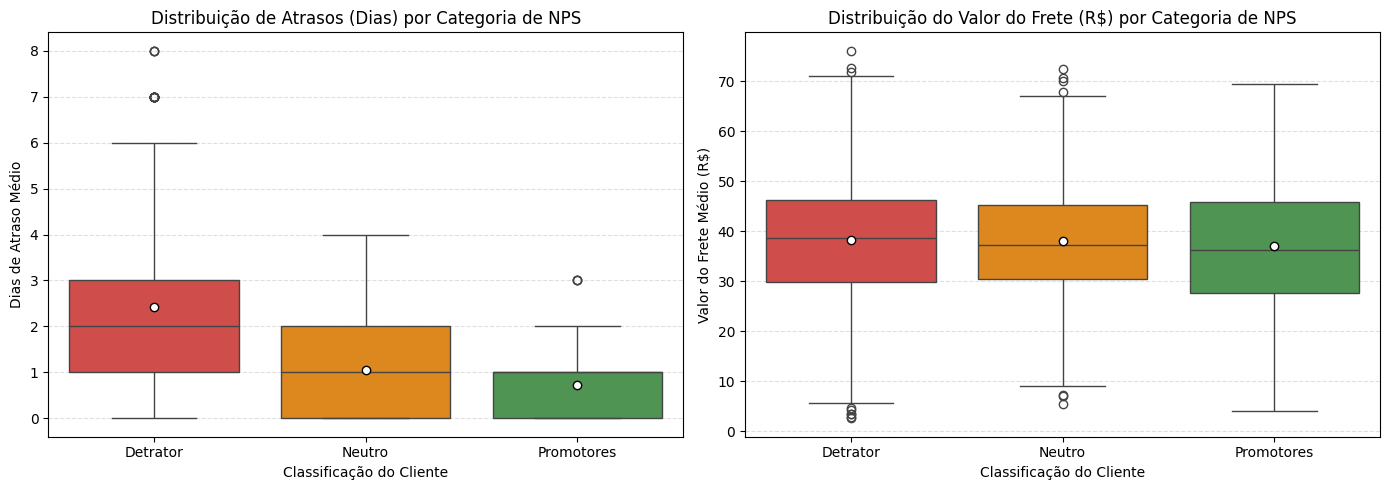

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Atraso na Entrega
sns.boxplot(
    data=perfil_cliente,
    x="clas_cliente",
    y="delivery_delay_days",
    palette=["#E53935", "#FB8C00", "#43A047"],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
    },
    ax=axes[0],
)
axes[0].set_title(
    "Distribuição de Atrasos (Dias) por Categoria de NPS", fontsize=12
)
axes[0].set_xlabel("Classificação do Cliente")
axes[0].set_ylabel("Dias de Atraso Médio")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Gráfico 2: Custo de Frete Médio
sns.boxplot(
    data=perfil_cliente,
    x="clas_cliente",
    y="freight_value",
    palette=["#E53935", "#FB8C00", "#43A047"],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
    },
    ax=axes[1],
)
axes[1].set_title(
    "Distribuição do Valor do Frete (R$) por Categoria de NPS", fontsize=12
)
axes[1].set_xlabel("Classificação do Cliente")
axes[1].set_ylabel("Valor do Frete Médio (R$)")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [60]:
dados.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score',
       'clas_cliente'],
      dtype='object')

'delivery_delay_days',
    'complaints_count',
    'resolution_time_days',
    'customer_service_contacts'

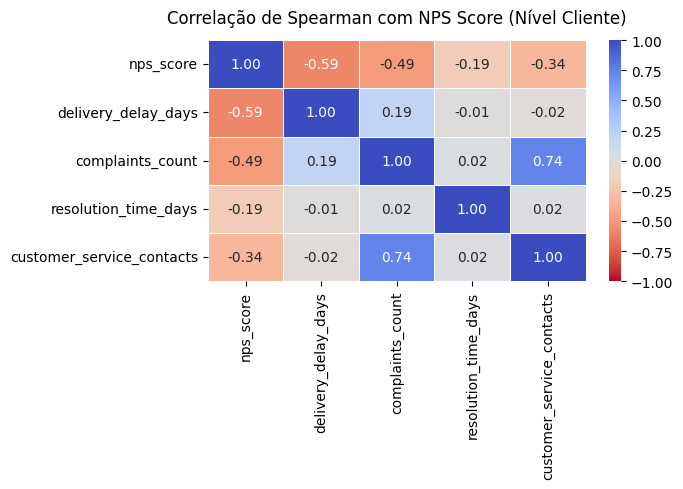

In [61]:
cols_correlacao = [
    "nps_score",
    'delivery_delay_days',
    'complaints_count',
    'resolution_time_days',
    'customer_service_contacts',
]
corr_matrix = dados[cols_correlacao].corr(
    method="spearman"
)  # Spearman é ideal para dados ordinais como NPS

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm_r",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title(
    "Correlação de Spearman com NPS Score (Nível Cliente)", fontsize=12, pad=12
)
plt.tight_layout()
plt.show()

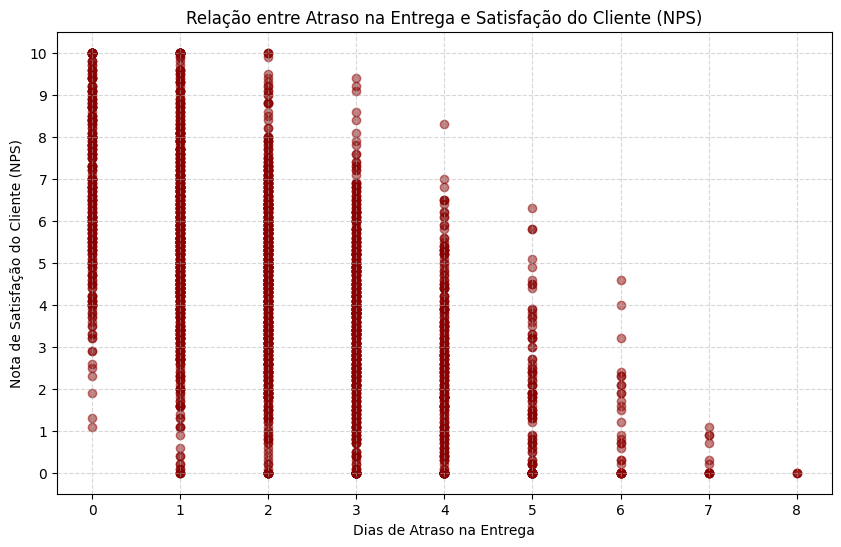

In [62]:
# Visualizando os dados: NPS vs Atraso na Entrega
plt.figure(figsize=(10, 6)) # Define o tamanho da figura (opcional, mas recomendado)

# O gráfico de dispersão:
# Eixo X (horizontal): 'delivery_delay_days' (Quantidade de dias de atraso na entrega)
# Eixo Y (vertical): 'nps_score' (Nota de satisfação do cliente (NPS), de 0 a 10)
plt.scatter(dados['delivery_delay_days'], dados['nps_score'], alpha=0.5, color='darkred')

# Rótulos e Título claros e informativos
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('Nota de Satisfação do Cliente (NPS)')
plt.title('Relação entre Atraso na Entrega e Satisfação do Cliente (NPS)')

# Exibe as notas do NPS no eixo Y (0 a 10)
plt.yticks(range(11))

# Adiciona uma grade para facilitar a leitura (opcional, mas útil)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [63]:
# Dividindo os dados em conjuntos de treinamento e teste
X = dados[['delivery_delay_days']]  # Recurso (variável independente)
y = dados['nps_score']  # Rótulo (variável dependente)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
dados.shape

(2500, 20)

In [65]:
X_train.shape

(2000, 1)

In [66]:
X_test.shape

(500, 1)

## MODELO 1 SIMPLES REGRESSAO


In [67]:
# Criando e treinando o modelo de regressão linear
modelo = LinearRegression()
modelo.fit(X_train, y_train) # treina o modelo

LinearRegression()

In [68]:
# Fazendo previsões no conjunto de teste
previsoes = modelo.predict(X_test)

In [69]:
previsoes


array([ 5.60319718,  4.57882166,  6.62757271,  4.57882166,  5.60319718,
        2.53007061,  1.50569509,  5.60319718,  3.55444614,  3.55444614,
        5.60319718,  5.60319718,  4.57882166,  5.60319718,  4.57882166,
        4.57882166,  4.57882166,  5.60319718,  6.62757271,  3.55444614,
        1.50569509,  4.57882166,  3.55444614,  4.57882166,  4.57882166,
        4.57882166,  3.55444614,  3.55444614,  5.60319718,  3.55444614,
        4.57882166,  3.55444614,  2.53007061,  2.53007061,  3.55444614,
        4.57882166,  4.57882166,  6.62757271,  5.60319718,  5.60319718,
        5.60319718,  4.57882166,  4.57882166,  3.55444614, -1.56743149,
        5.60319718,  5.60319718,  1.50569509,  5.60319718,  4.57882166,
        6.62757271,  5.60319718,  6.62757271,  4.57882166,  5.60319718,
        5.60319718,  5.60319718,  2.53007061,  6.62757271,  4.57882166,
        5.60319718,  5.60319718,  3.55444614,  2.53007061,  4.57882166,
        4.57882166,  2.53007061,  3.55444614,  5.60319718,  6.62

Erro Médio Quadrático (MSE): 3.79
Erro Absoluto Médio (MAE): 1.58
R² (coeficiente de determinação): 0.40


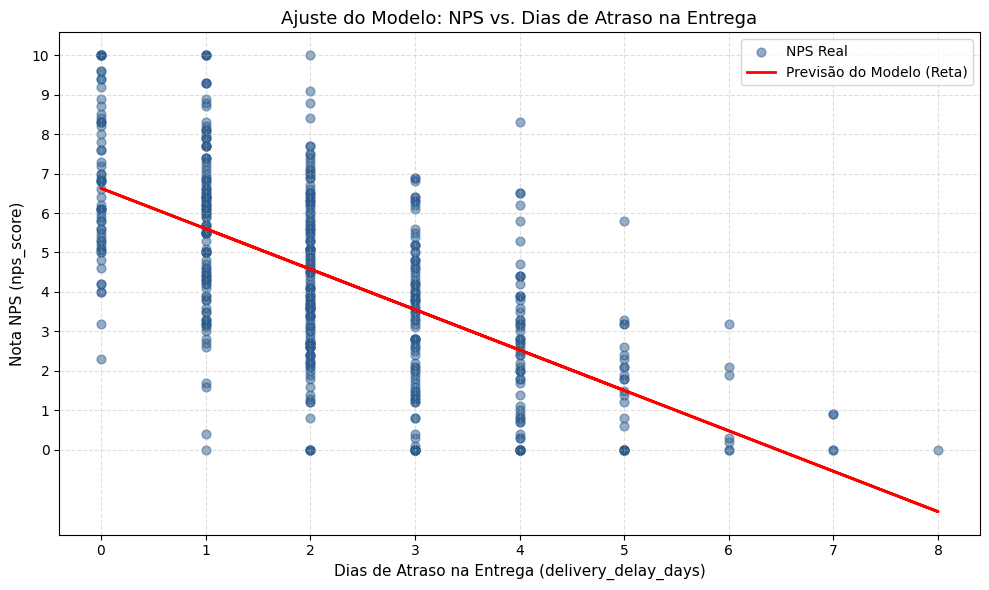

In [70]:
# Avaliando o desempenho do modelo
erro_medio_quadratico = mean_squared_error(y_test, previsoes)
erro_absoluto_medio = mean_absolute_error(y_test, previsoes)
r_quadrado = r2_score(y_test, previsoes)

print(f"Erro Médio Quadrático (MSE): {erro_medio_quadratico:.2f}")
print(f"Erro Absoluto Médio (MAE): {erro_absoluto_medio:.2f}")
print(f"R² (coeficiente de determinação): {r_quadrado:.2f}")

# Visualizando as previsões do modelo
plt.figure(figsize=(10, 6))

# Pontos reais do conjunto de teste
plt.scatter(
    X_test, y_test, color="#2b5c8f", alpha=0.5, label="NPS Real", s=40
)

# Reta com as previsões do modelo de regressão
# (Como é uma regressão linear simples com 1 variável, traçar como linha evidencia a tendência)
plt.plot(
    X_test,
    previsoes,
    color="red",
    linewidth=2,
    label="Previsão do Modelo (Reta)",
)

plt.title("Ajuste do Modelo: NPS vs. Dias de Atraso na Entrega", fontsize=13)
plt.xlabel("Dias de Atraso na Entrega (delivery_delay_days)", fontsize=11)
plt.ylabel("Nota NPS (nps_score)", fontsize=11)
plt.yticks(range(11))
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

## MODELO 2 REGRESSAO MULTIPLA

In [71]:
# Incluindo os fatores de atrito no suporte e logística
features = [
    'delivery_delay_days',
    'complaints_count',
    'resolution_time_days',
    'customer_service_contacts'
]

X = dados[features]
y = dados['nps_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
# 1. Seleção das variáveis explicativas (Features) e variável-alvo (Target)
features = [
    'delivery_delay_days',
    'complaints_count',
    'resolution_time_days',
    'customer_service_contacts',
]

X_mult = dados[features]
y_mult = dados['nps_score']

# 2. Divisão em Treino (80%) e Teste (20%) com a mesma semente para comparação justa
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mult, y_mult, test_size=0.2, random_state=42
)

# 3. Treinamento do Modelo
modelo_mult = LinearRegression()
modelo_mult.fit(X_train_m, y_train_m)

# 4. Previsões no conjunto de teste
previsoes_mult = modelo_mult.predict(X_test_m)

# 5. Avaliação das Métricas
mse_m = mean_squared_error(y_test_m, previsoes_mult)
mae_m = mean_absolute_error(y_test_m, previsoes_mult)
r2_m = r2_score(y_test_m, previsoes_mult)

print('=== DESEMPENHO: REGRESSÃO LINEAR MÚLTIPLA ===')
print(f'Erro Médio Quadrático (MSE): {mse_m:.2f}')
print(f'Erro Absoluto Médio (MAE): {mae_m:.2f}')
print(f'R² (Coeficiente de Determinação): {r2_m:.2f}\n')

# 6. Impacto relativo de cada variável (Pesos/Coeficientes do modelo)
coeficientes = pd.DataFrame(
    {'Variável': features, 'Impacto na Nota (Coeficiente)': modelo_mult.coef_}
).sort_values(by='Impacto na Nota (Coeficiente)')

print('=== PESO DE CADA VARIÁVEL NO NPS ===')
print(coeficientes.to_string(index=False))

=== DESEMPENHO: REGRESSÃO LINEAR MÚLTIPLA ===
Erro Médio Quadrático (MSE): 2.80
Erro Absoluto Médio (MAE): 1.32
R² (Coeficiente de Determinação): 0.56

=== PESO DE CADA VARIÁVEL NO NPS ===
                 Variável  Impacto na Nota (Coeficiente)
      delivery_delay_days                      -0.942191
         complaints_count                      -0.387023
customer_service_contacts                      -0.332168
     resolution_time_days                      -0.145913


## MODELO RANDOM FOREST

In [73]:

# 1. Seleção das variáveis explicativas (Features) e variável-alvo (Target)
features = [
    'delivery_delay_days',
    'complaints_count',
    'resolution_time_days',
    'customer_service_contacts',
]

X_rf = dados[features]
y_rf = dados['nps_score']

# 2. Divisão em Treino (80%) e Teste (20%)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

# 3. Treinamento do Modelo Random Forest
modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
modelo_rf.fit(X_train_rf, y_train_rf)

# 4. Previsões no conjunto de teste
previsoes_rf = modelo_rf.predict(X_test_rf)

# 5. Avaliação das Métricas
mse_rf = mean_squared_error(y_test_rf, previsoes_rf)
mae_rf = mean_absolute_error(y_test_rf, previsoes_rf)
r2_rf = r2_score(y_test_rf, previsoes_rf)

print('=== DESEMPENHO: RANDOM FOREST REGRESSOR ===')
print(f'Erro Médio Quadrático (MSE): {mse_rf:.2f}')
print(f'Erro Absoluto Médio (MAE): {mae_rf:.2f}')
print(f'R² (Coeficiente de Determinação): {r2_rf:.2f}\n')

# 6. Importância relativa de cada variável (Feature Importance)
importancias = pd.DataFrame(
    {
        'Variável': features,
        'Importância Relativa (%)': modelo_rf.feature_importances_ * 100,
    }
).sort_values(by='Importância Relativa (%)', ascending=False)

print('=== IMPORTÂNCIA DE CADA VARIÁVEL NO NPS ===')
print(importancias.to_string(index=False, float_format='{:.2f}%'.format))

=== DESEMPENHO: RANDOM FOREST REGRESSOR ===
Erro Médio Quadrático (MSE): 3.33
Erro Absoluto Médio (MAE): 1.46
R² (Coeficiente de Determinação): 0.47

=== IMPORTÂNCIA DE CADA VARIÁVEL NO NPS ===
                 Variável  Importância Relativa (%)
      delivery_delay_days                    42.64%
         complaints_count                    28.99%
     resolution_time_days                    16.90%
customer_service_contacts                    11.47%


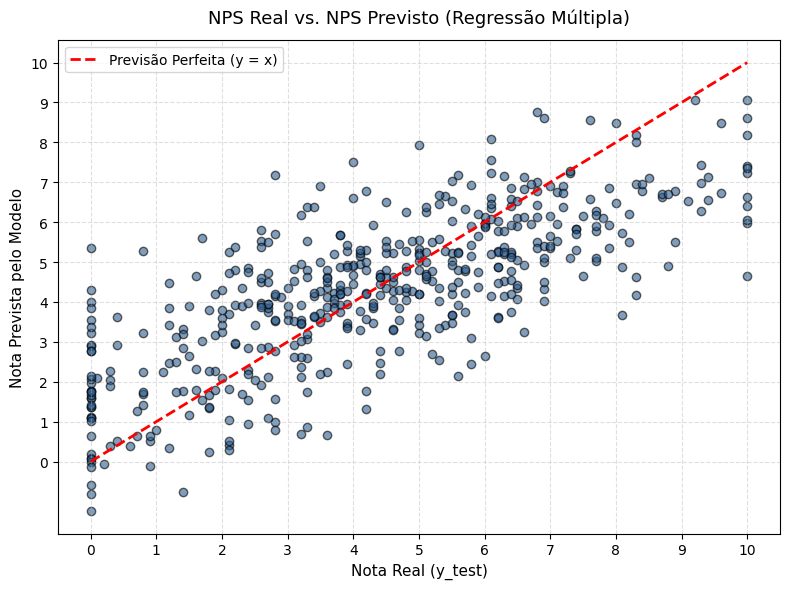

In [74]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_m, previsoes_mult, color='#2b5c8f', alpha=0.6, edgecolors='k')
plt.plot([0, 10], [0, 10], color='red', linestyle='--', linewidth=2, label='Previsão Perfeita (y = x)')

plt.title('NPS Real vs. NPS Previsto (Regressão Múltipla)', fontsize=13, pad=12)
plt.xlabel('Nota Real (y_test)', fontsize=11)
plt.ylabel('Nota Prevista pelo Modelo', fontsize=11)
plt.xticks(range(11))
plt.yticks(range(11))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

In [75]:
print(coeficientes)

                    Variável  Impacto na Nota (Coeficiente)
0        delivery_delay_days                      -0.942191
1           complaints_count                      -0.387023
3  customer_service_contacts                      -0.332168
2       resolution_time_days                      -0.145913


In [76]:
# Filtrando clientes que deram nota baixa mesmo sem atraso relevante
detratores_sem_atraso = dados[
    (dados["delivery_delay_days"] == 0) & (dados["nps_score"] <= 6)
]

# Principais variáveis para checar desse grupo
cols_analise = [
    "customer_service_contacts",  # Entrou em contato com SAC?
    "complaints_count",  # Abriu reclamações?
    "resolution_time_days",  # Teve lentidão para resolver problemas?
    "delivery_attempts",  # O entregador tentou várias vezes?
    "repeat_purchase_30d",  # Voltou a comprar?
]

detratores_sem_atraso[cols_analise].describe().round(2)

,customer_service_contacts,complaints_count,resolution_time_days,delivery_attempts,repeat_purchase_30d
count,101.00,101.00,101.00,101.00,101.0
mean,2.12,4.15,6.64,1.99,0.0
std,1.22,1.95,3.25,0.82,0.0
min,0.00,0.00,0.00,1.00,0.0
25%,1.00,3.00,4.00,1.00,0.0
50%,2.00,4.00,7.00,2.00,0.0
75%,3.00,5.00,9.00,3.00,0.0
max,5.00,9.00,11.00,3.00,0.0


In [77]:
# 1. Definir os grupos de interesse
promotores = dados[dados["nps_score"] >= 9]
detratores_sem_atraso = dados[
    (dados["delivery_delay_days"] == 0) & (dados["nps_score"] <= 6)
]

cols_analise = [
    "customer_service_contacts",
    "complaints_count",
    "resolution_time_days",
    "delivery_attempts",
    "repeat_purchase_30d",
]

# 2. Criar tabela de comparação
comp = pd.DataFrame(
    {
        "Detratores (Sem Atraso)": detratores_sem_atraso[cols_analise].mean(),
        "Promotores (Geral)": promotores[cols_analise].mean(),
    }
)

# Adicionar a diferença absoluta
comp["Diferença (Detrator - Promotor)"] = (
    comp["Detratores (Sem Atraso)"] - comp["Promotores (Geral)"]
)

# Adicionar taxa de recompra em porcentagem para facilitar leitura
comp.loc["repeat_purchase_30d_pct"] = comp.loc["repeat_purchase_30d"] * 100

print(comp.round(2))

                           Detratores (Sem Atraso)  ...  Diferença (Detrator - Promotor)
customer_service_contacts                     2.12  ...                             1.45
complaints_count                              4.15  ...                             1.88
resolution_time_days                          6.64  ...                             2.94
delivery_attempts                             1.99  ...                            -0.16
repeat_purchase_30d                           0.00  ...                            -1.00
repeat_purchase_30d_pct                       0.00  ...                          -100.00

[6 rows x 3 columns]


/tmp/ipykernel_496/3278387303.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_496/3278387303.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_496/3278387303.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


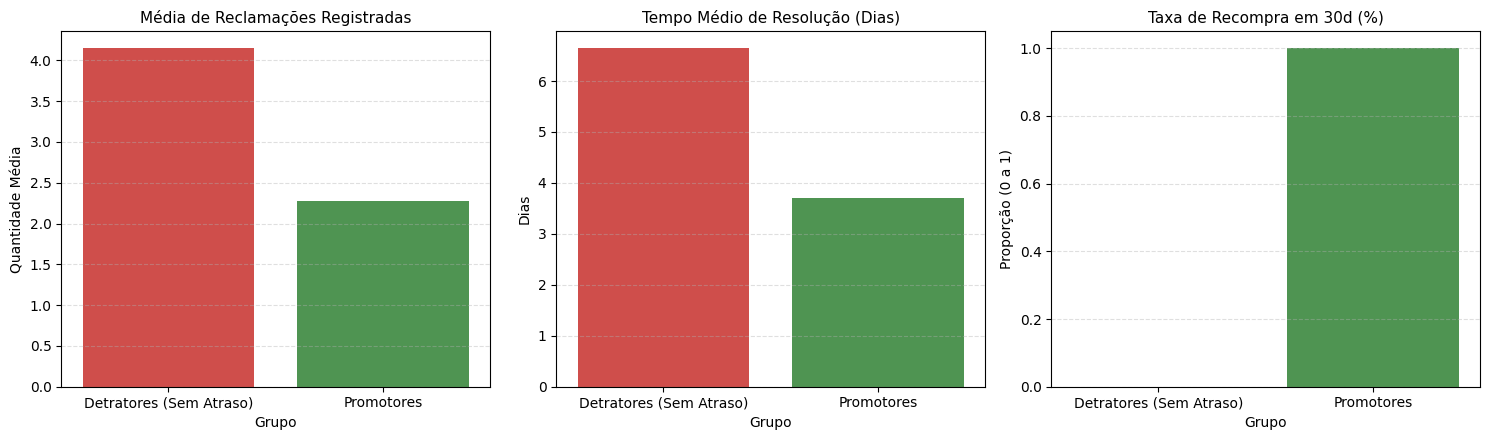

In [78]:
# Preparar DataFrame consolidado para plot
df_comp = pd.concat(
    [
        detratores_sem_atraso[cols_analise].assign(
            Grupo="Detratores (Sem Atraso)"
        ),
        promotores[cols_analise].assign(Grupo="Promotores"),
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Gráfico 1: Reclamações
sns.barplot(
    data=df_comp,
    x="Grupo",
    y="complaints_count",
    palette=["#E53935", "#43A047"],
    ax=axes[0],
    errorbar=None,
)
axes[0].set_title("Média de Reclamações Registradas", fontsize=11)
axes[0].set_ylabel("Quantidade Média")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Gráfico 2: Tempo de Resolução (Dias)
sns.barplot(
    data=df_comp,
    x="Grupo",
    y="resolution_time_days",
    palette=["#E53935", "#43A047"],
    ax=axes[1],
    errorbar=None,
)
axes[1].set_title("Tempo Médio de Resolução (Dias)", fontsize=11)
axes[1].set_ylabel("Dias")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

# Gráfico 3: Taxa de Recompra em 30 Dias
sns.barplot(
    data=df_comp,
    x="Grupo",
    y="repeat_purchase_30d",
    palette=["#E53935", "#43A047"],
    ax=axes[2],
    errorbar=None,
)
axes[2].set_title("Taxa de Recompra em 30d (%)", fontsize=11)
axes[2].set_ylabel("Proporção (0 a 1)")
axes[2].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [79]:
# 1. Aplicação da sua função na base
dados['clas_cliente'] = dados.apply(classificador_nps, axis=1)
ordem_nps = ['Detrator', 'Neutro', 'Promotores']
cores_nps = ['#E53935', '#FB8C00', '#43A047']

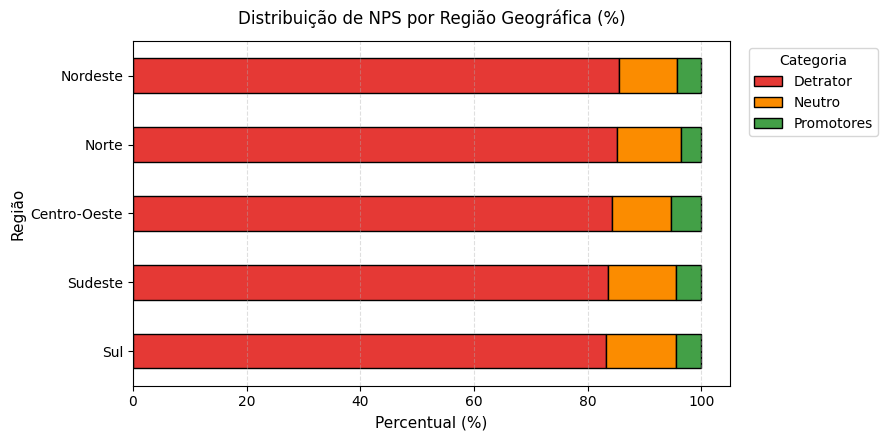

clas_cliente     Detrator  Neutro  Promotores
customer_region                              
Nordeste             85.6    10.1         4.3
Norte                85.2    11.3         3.6
Centro-Oeste         84.2    10.5         5.3
Sudeste              83.7    11.9         4.4
Sul                  83.3    12.3         4.4


In [80]:
# Tabela de contingência percentual por região
regiao_dist = pd.crosstab(
    dados['customer_region'],
    dados['clas_cliente'],
    normalize='index'
)[ordem_nps] * 100

# Ordena pela maior concentração de Detratores
regiao_dist = regiao_dist.sort_values(by='Detrator', ascending=False)

# Gráfico de barras horizontais empilhadas
ax = regiao_dist.plot(
    kind='barh',
    stacked=True,
    color=cores_nps,
    figsize=(9, 4.5),
    edgecolor='black'
)

plt.title('Distribuição de NPS por Região Geográfica (%)', fontsize=12, pad=12)
plt.xlabel('Percentual (%)', fontsize=11)
plt.ylabel('Região', fontsize=11)
plt.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(regiao_dist.round(1))

In [81]:
cols_analise = [
    'customer_age',              # Idade
    'customer_tenure_months',    # Tempo de casa (meses)
    'items_quantity',            # Quantidade de itens
    'discount_value',            # Desconto aplicado
    'payment_installments',      # Número de parcelas
    'delivery_time_days',        # Tempo total de entrega (dias)
    'csat_internal_score'        # Score interno de satisfação
]

tabela_medias = dados.groupby('clas_cliente')[cols_analise].mean().reindex(ordem_nps)
print(tabela_medias.round(2).T)

clas_cliente            Detrator  Neutro  Promotores
customer_age               43.40   43.25       43.63
customer_tenure_months     61.43   59.83       63.00
items_quantity              3.48    3.31        3.64
discount_value             29.44   30.84       32.75
payment_installments        5.98    6.28        5.81
delivery_time_days          7.99    8.26        7.94
csat_internal_score         2.54    4.77        6.04


/tmp/ipykernel_496/2163358231.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_496/2163358231.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_496/2163358231.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


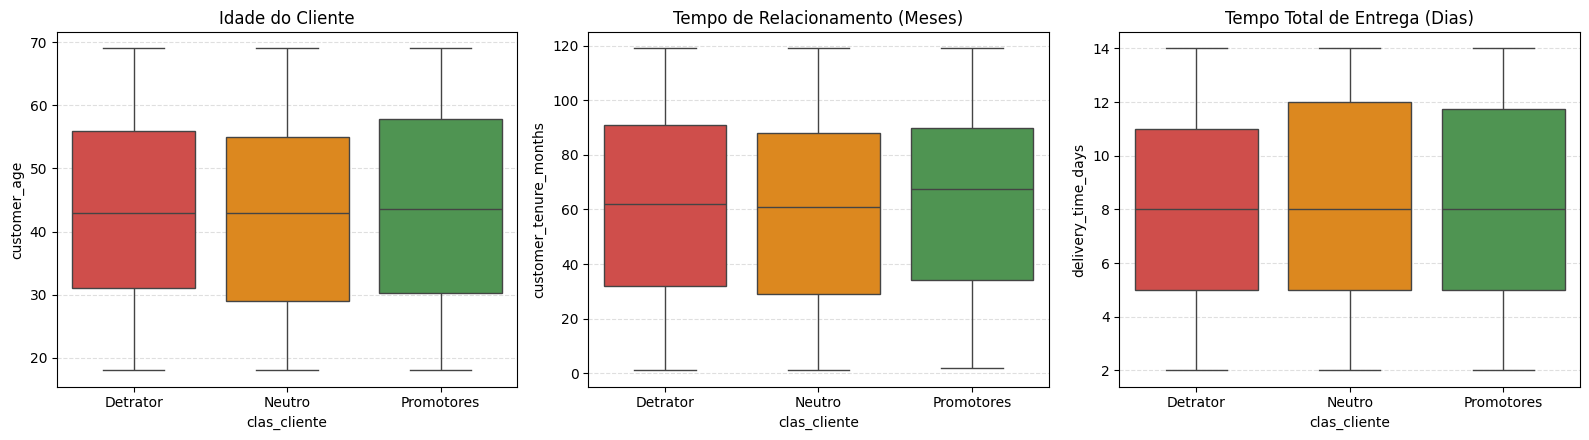

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Idade vs NPS
sns.boxplot(
    data=dados,
    x='clas_cliente',
    y='customer_age',
    order=ordem_nps,
    palette=cores_nps,
    ax=axes[0]
)
axes[0].set_title('Idade do Cliente')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Tempo de Relacionamento (Tenure) vs NPS
sns.boxplot(
    data=dados,
    x='clas_cliente',
    y='customer_tenure_months',
    order=ordem_nps,
    palette=cores_nps,
    ax=axes[1]
)
axes[1].set_title('Tempo de Relacionamento (Meses)')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Tempo Total de Entrega vs NPS
sns.boxplot(
    data=dados,
    x='clas_cliente',
    y='delivery_time_days',
    order=ordem_nps,
    palette=cores_nps,
    ax=axes[2]
)
axes[2].set_title('Tempo Total de Entrega (Dias)')
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()